## Setup

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
victorsoeiro_amazon_prime_tv_shows_and_movies_path = kagglehub.dataset_download('victorsoeiro/amazon-prime-tv-shows-and-movies')

print('Data source import complete.')

Data source import complete.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import gc

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk(victorsoeiro_amazon_prime_tv_shows_and_movies_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

C:\Users\aaron\.cache\kagglehub\datasets\victorsoeiro\amazon-prime-tv-shows-and-movies\versions\1\credits.csv
C:\Users\aaron\.cache\kagglehub\datasets\victorsoeiro\amazon-prime-tv-shows-and-movies\versions\1\titles.csv


In [3]:
credits = pd.read_csv(r'C:\Users\aaron\.cache\kagglehub\datasets\victorsoeiro\amazon-prime-tv-shows-and-movies\versions\1\credits.csv')
credits.head()

,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


In [4]:
titles = pd.read_csv(r'C:\Users\aaron\.cache\kagglehub\datasets\victorsoeiro\amazon-prime-tv-shows-and-movies\versions\1\titles.csv')

# filtrado de calidad de los datos
titles = titles[~(titles['imdb_score'].isnull() | titles['imdb_votes'].isnull())]
titles = titles[~(titles['imdb_votes'] <= 30)]
titles.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8071 entries, 0 to 9869
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    8071 non-null   object 
 1   title                 8071 non-null   object 
 2   type                  8071 non-null   object 
 3   description           8062 non-null   object 
 4   release_year          8071 non-null   int64  
 5   age_certification     3099 non-null   object 
 6   runtime               8071 non-null   int64  
 7   genres                8071 non-null   object 
 8   production_countries  8071 non-null   object 
 9   seasons               1003 non-null   float64
 10  imdb_id               8071 non-null   object 
 11  imdb_score            8071 non-null   float64
 12  imdb_votes            8071 non-null   float64
 13  tmdb_popularity       7933 non-null   float64
 14  tmdb_score            7104 non-null   float64
dtypes: float64(5), int64(2), o

## Preprocesamiento

In [5]:
grouped = credits.groupby(['id', 'role'])['name'].apply(list).to_dict()

def get_credits(id_title, role):
    '''
    role es 'DIRECTOR' o 'ACTOR'
    '''
    if (id_title, role) in grouped.keys():
        return str(grouped[id_title, role]).replace("'", '')[1:-1]
    else:
        return ''

def transform(dataframe):
    df = dataframe.copy()

    df['type'] = (df['type'] == 'MOVIE').astype(int)

    # llena los valores nulos
    df['title'] = df['title'].fillna('')
    df['description'] = df['description'].fillna('')
    df['seasons'] = df['seasons'].fillna(1).astype(int)
    df['age_certification'] = df['age_certification'].fillna('Unrated')

    # elimina comillas
    df['genres'] = df['genres'].str.replace("'", "").str.replace("[", "").str.replace("]", "")
    df['production_countries'] = df['production_countries'].str.replace("'", "").str.replace("[", "").str.replace("]", "")

    # agrega los creditos
    directors = []
    actors = []
    for id_title in df['id']:
        director = get_credits(id_title, 'DIRECTOR')
        actor = get_credits(id_title, 'ACTOR')
        directors.append(director)
        actors.append(actor)
    
    df['directors'] = directors
    df['actors'] = actors

    # fija el id como un entero
    df['id'] = df['id'].str.extract(r'(\d+)', expand=False).astype(int)
    df.set_index('id', inplace=True)

    return df[['title', 'type', 'description', 'release_year', 'runtime', 'genres', 'production_countries', 'seasons', 'directors', 'actors', 'imdb_score']]

titles = transform(titles)
titles.info()
del grouped

<class 'pandas.core.frame.DataFrame'>
Index: 8071 entries, 20945 to 1054116
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 8071 non-null   object 
 1   type                  8071 non-null   int64  
 2   description           8071 non-null   object 
 3   release_year          8071 non-null   int64  
 4   runtime               8071 non-null   int64  
 5   genres                8071 non-null   object 
 6   production_countries  8071 non-null   object 
 7   seasons               8071 non-null   int64  
 8   directors             8071 non-null   object 
 9   actors                8071 non-null   object 
 10  imdb_score            8071 non-null   float64
dtypes: float64(1), int64(4), object(6)
memory usage: 756.7+ KB


In [6]:
titles.head(3)

,title,type,description,release_year,runtime,genres,production_countries,seasons,directors,actors,imdb_score
id,,,,,,,,,,,
20945,The Three Stooges,0,The Three Stooges were an American vaudeville ...,1934,19,"comedy, family, animation, action, fantasy, ho...",US,26,,"Joe Besser, Moe Howard, Larry Fine",8.6
19248,The General,1,"During America’s Civil War, Union spies steal ...",1926,78,"action, drama, war, western, comedy, european",US,1,"Clyde Bruckman, Buster Keaton","Buster Keaton, Marion Mack, Glen Cavender, Jim...",8.2
82253,The Best Years of Our Lives,1,It's the hope that sustains the spirit of ever...,1946,171,"romance, war, drama",US,1,William Wyler,"Myrna Loy, Fredric March, Dana Andrews, Teresa...",8.1


El id original se recupera uniendo type(tm o ts) + id

In [ ]:
LINGUAL_FEATURES = ['title', 'description', 'genres', 'production_countries', 'directors', 'actors']
NUMERICAL_FEATURES = ['type', 'release_year', 'runtime', 'seasons']

def transform2(dataframe):
    df = dataframe.copy()
    df['lingual'] = df['title']

    for feature in LINGUAL_FEATURES[1:]:
        df['lingual'] += ' ' + df[feature]

    df['lingual'] = df['lingual'].astype(str)
    return df[['lingual'] + NUMERICAL_FEATURES + ['imdb_score']]

titles = transform2(titles)
titles.head()

,lingual,type,release_year,runtime,seasons,imdb_score
id,,,,,,
20945,The Three Stooges The Three Stooges were an Am...,0,1934,19,26,8.6
19248,"The General During America’s Civil War, Union ...",1,1926,78,1,8.2
82253,The Best Years of Our Lives It's the hope that...,1,1946,171,1,8.1
83884,"His Girl Friday Hildy, the journalist former w...",1,1940,92,1,7.8
56584,In a Lonely Place An aspiring actress begins t...,1,1950,94,1,7.9


## Separacion de datos

In [8]:
from sklearn.model_selection import train_test_split

titles_desarrollo, titles_eval = train_test_split(titles, test_size=0.15, random_state=28, shuffle=True)
print(f"Desarrollo: {titles_desarrollo.shape[0]} titulos")
print(f"Evaluacion: {titles_eval.shape[0]} titulos")

Desarrollo: 6860 titulos
Evaluacion: 1211 titulos


Mantengo la proporcion de type y age_certification

In [9]:
titles_train, titles_val = train_test_split(titles_desarrollo, test_size=0.2, random_state=28, shuffle=True, stratify=titles_desarrollo['type'])
print(f"Entrenamiento: {titles_train.shape[0]} titulos")
print(f"Validacion: {titles_val.shape[0]} titulos")

Entrenamiento: 5488 titulos
Validacion: 1372 titulos


## Model 0

In [10]:
X_train = titles_train[['type', 'release_year', 'runtime', 'seasons']]
y_train = titles_train['imdb_score']

X_val = titles_val[['type', 'release_year', 'runtime', 'seasons']]
y_val = titles_val['imdb_score']

In [11]:
from sklearn.ensemble import GradientBoostingRegressor

# Entrenamiento de un modelo Gradient Boosting
gbm = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=28)
gbm.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error

# Predicción y evaluación
y_pred_gbm = gbm.predict(X_val)
mse_gbm = mean_squared_error(y_val, y_pred_gbm)
print(f"MSE (GradientBoosting) en la validación: {mse_gbm:.2f}")

MSE (GradientBoosting) en la validación: 1.26


## Torch setup

In [12]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from transformers import BertTokenizer, BertModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")
torch.cuda.set_per_process_memory_fraction(0.75)

Usando dispositivo: cuda


In [13]:
# Using English BERT model
model_name = "bert-base-multilingual-cased"
tokenizer = BertTokenizer.from_pretrained(model_name)

texto = titles_train['lingual'].iloc[1]*5
tokens = tokenizer.tokenize(texto)
print(texto)
print(tokens)
print(tokenizer.encode(texto, truncation=True))


Black Jesus A thinly-disguised biography of African leader Patrice Lumumba, here called Lalubi. Lalubi, a Christ-like leader determined to save his people, by passive resistance, from the dictatorial regime propped up by European colonialists, is imprisoned and tortured, along with a thief who comes to a greater understanding through his contact with Lalubi. drama IT Valerio Zurlini Woody Strode, Franco Citti, Jean Servais, Pier Paolo Capponi, Stephen Forsyth, Salvatore Basile, Giuseppe Transocchi, Renzo Rossi, Inigo Lezzi, Bruno CorazzariBlack Jesus A thinly-disguised biography of African leader Patrice Lumumba, here called Lalubi. Lalubi, a Christ-like leader determined to save his people, by passive resistance, from the dictatorial regime propped up by European colonialists, is imprisoned and tortured, along with a thief who comes to a greater understanding through his contact with Lalubi. drama IT Valerio Zurlini Woody Strode, Franco Citti, Jean Servais, Pier Paolo Capponi, Stephen

In [14]:
bertmodel = BertModel.from_pretrained(model_name).to(device).eval()

tokens = torch.tensor(tokenizer.encode(texto, truncation=True)).to(device).unsqueeze(0)
hidden = bertmodel(tokens)
hidden

BaseModelOutputWithPoolingAndCrossAttentions(last_hidden_state=tensor([[[ 0.0349,  0.0812, -0.2178,  ...,  0.2180,  0.1916, -0.0456],
         [-0.0265,  0.0448,  0.3576,  ...,  1.2931,  0.1752, -0.3807],
         [ 0.3244, -0.3951,  0.9583,  ...,  0.4795,  0.3277, -0.1338],
         ...,
         [-0.6660, -0.6411, -0.5158,  ...,  0.3360,  0.2619,  0.2647],
         [-0.3705, -0.8220,  0.9206,  ...,  0.5358,  0.6631, -0.5685],
         [ 0.0583, -0.3728, -0.0048,  ..., -0.3957,  0.0461, -0.0559]]],
       device='cuda:0', grad_fn=<NativeLayerNormBackward0>), pooler_output=tensor([[ 0.2715, -0.1129,  0.2028, -0.2645, -0.0660,  0.2272,  0.2408,  0.2087,
         -0.2650,  0.1863, -0.0167, -0.1833, -0.1020, -0.2139,  0.1788, -0.2066,
          0.4870,  0.0310,  0.1508, -0.2173, -1.0000, -0.1019, -0.2948, -0.0480,
         -0.3828,  0.1025, -0.1128,  0.1874,  0.0978, -0.1270,  0.0230, -1.0000,
          0.5095,  0.5724,  0.1419, -0.1231,  0.1151,  0.1967,  0.1785, -0.3571,
         -0.077

Token indices sequence length is longer than the specified maximum sequence length for this model (577 > 512). Running this sequence through the model will result in indexing errors


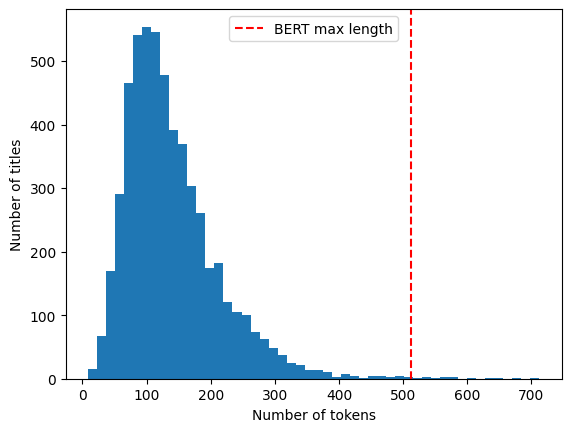

In [15]:
import matplotlib.pyplot as plt

# compute token counts (including [CLS] and [SEP])
token_counts = titles_train['lingual'].apply(
    lambda txt: len(tokenizer.encode(txt))
)

plt.hist(token_counts, bins=50)
plt.axvline(512, color='r', linestyle='--', label='BERT max length')
plt.xlabel("Number of tokens")
plt.ylabel("Number of titles")
plt.legend()
plt.show()

## CSL

In [16]:
# Load the BERT model
bertmodel = BertModel.from_pretrained(model_name).to(device).eval()

from torch.utils.data import Dataset

class dataset_token(Dataset):
    def __init__(self, titles, _hiddens):
        self.pairs = list(zip(_hiddens,
                              titles['type'],
                              titles['release_year'],
                              titles['runtime'],
                              titles['seasons'],
                              titles['imdb_score']))
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        _hidden, type, release_year, runtime, seasons, imdb_score = self.pairs[idx]
        out = {}

        out['input_lingual'] = _hidden.to(device)

        for name, feat in zip(NUMERICAL_FEATURES, [type, release_year, runtime, seasons]):
            out[f'input_{name}'] = torch.tensor(feat, dtype=torch.float).to(device)

        out['target'] = torch.tensor(imdb_score, dtype=torch.float).to(device)
        return out

def get_hiddens_lingual(titles):
    titles_lingual = []

    with torch.inference_mode():
        for lingual in titles['lingual']:
            tokens = torch.tensor(tokenizer.encode(lingual, truncation=True)).to(device).unsqueeze(0)
            hidden = bertmodel(tokens).last_hidden_state.squeeze(0)
            hidden = hidden.cpu()
            titles_lingual.append(hidden)
            torch.cuda.empty_cache()

    return titles_lingual

titles_train_hidden = get_hiddens_lingual(titles_train)
titles_val_hidden = get_hiddens_lingual(titles_val)

train_dataset = dataset_token(titles_train, titles_train_hidden)
val_dataset = dataset_token(titles_val, titles_val_hidden)

print('Primer elemento del dataset de entrenamiento:', train_dataset[1])

del bertmodel
torch.cuda.empty_cache()
gc.collect()

Primer elemento del dataset de entrenamiento: {'input_lingual': tensor([[-0.0124, -0.0665, -0.1682,  ...,  0.4652,  0.2823,  0.1036],
        [ 0.1313,  0.0224,  1.0462,  ...,  1.1825,  0.6013, -0.2825],
        [ 0.2925, -0.3585,  0.9935,  ...,  0.5656,  0.3963,  0.0398],
        ...,
        [-0.0096, -0.2282, -0.7105,  ...,  1.3239,  0.2032,  0.1454],
        [-0.1791, -0.9001, -0.4005,  ...,  0.3522,  0.3379, -0.0637],
        [-0.2104, -0.4039,  0.1977,  ...,  0.4076,  0.1387,  0.3249]],
       device='cuda:0'), 'input_type': tensor(1., device='cuda:0'), 'input_release_year': tensor(1968., device='cuda:0'), 'input_runtime': tensor(89., device='cuda:0'), 'input_seasons': tensor(1., device='cuda:0'), 'target': tensor(6.5000, device='cuda:0')}


5840

## Auxiliar functions

In [17]:
import time

def train(model, train_dataloader, val_dataloader, optimizer, criterion, NUM_EPOCHS):
    train_losses = []
    val_losses = []

    print("Iniciando entrenamiento...")
    print("-" * 50)
    start_time = time.time()
    for epoch in range(NUM_EPOCHS):
        # Entrenamiento
        model.train()
        train_loss = 0
        n = 0

        for batch_idx, batch in enumerate(train_dataloader):
            input_lingual = batch['input_lingual']
            input_type = batch['input_type'].unsqueeze(1).to(device)
            input_release_year = batch['input_release_year'].unsqueeze(1).to(device)
            input_runtime = batch['input_runtime'].unsqueeze(1).to(device)
            input_seasons = batch['input_seasons'].unsqueeze(1).to(device)

            target = batch['target'].unsqueeze(1).to(device)

            optimizer.zero_grad()

            output = model.forward(input_lingual, input_type, input_release_year, input_runtime, input_seasons)
            loss = criterion(output, target)

            loss.backward()

            # Gradient clipping para evitar exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            train_loss += loss.item()
            n += 1

        train_loss /= n
        train_losses.append(train_loss)

        # Validación
        model.eval()
        val_loss = 0
        m = 0
        with torch.no_grad():
            for batch_idx, batch in enumerate(val_dataloader):
                input_lingual = batch['input_lingual']
                input_type = batch['input_type'].unsqueeze(1).to(device)
                input_release_year = batch['input_release_year'].unsqueeze(1).to(device)
                input_runtime = batch['input_runtime'].unsqueeze(1).to(device)
                input_seasons = batch['input_seasons'].unsqueeze(1).to(device)
                target = batch['target'].unsqueeze(1).to(device)

                output = model.forward(input_lingual, input_type, input_release_year, input_runtime, input_seasons)
                loss = criterion(output, target)
                val_loss += loss.item()
                m += 1
        val_loss /= m
        val_losses.append(val_loss)

        if (epoch + 1) % 5 == 0:
            print(f'Época {epoch+1}/{NUM_EPOCHS}')
            print(f'  Pérdida Entrenamiento: {train_loss:.4f}')
            print(f'  Pérdida Testeo: {val_loss:.4f}')
            print(f'  {"Mejorando" if val_loss < min(val_losses[:-1] + [float("inf")]) else "Empeorando"}')
    
    end_time = time.time()
    print(f"Entrenamiento completado! Tiempo total: {end_time - start_time:.2f} segundos")
    return train_losses, val_losses

In [18]:
from torch.nn.utils.rnn import pad_sequence

def custom_collate(batch):
    lingual_seqs = [item['input_lingual'] for item in batch]
    padded_lingual = pad_sequence(lingual_seqs, batch_first=True)

    type = torch.stack([item['input_type'] for item in batch])
    release_years = torch.stack([item['input_release_year'] for item in batch])
    runtimes = torch.stack([item['input_runtime'] for item in batch])
    seasons = torch.stack([item['input_seasons'] for item in batch])
    targets = torch.stack([item['target'] for item in batch])

    return {
        'input_lingual': padded_lingual,
        'input_type': type,
        'input_release_year': release_years,
        'input_runtime': runtimes,
        'input_seasons': seasons,
        'target': targets
    }

## Model 1

In [ ]:
class model1(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.Linear1 = nn.Linear(in_features=hidden_size + 4, out_features=10)
        self.sigmoid = nn.Sigmoid()
        self.Linear2 = nn.Linear(in_features=10, out_features=1)
        self.drop = nn.Dropout(0.5)

    def forward(self, input_lingual, input_type, input_release_year, input_runtime, input_seasons):
        # input_lingual: (batch, time, features)
        CLS_row = input_lingual[:, 0, :]
        CLS_row = self.drop(CLS_row)

        output = torch.cat((CLS_row, input_type, input_release_year, input_runtime, input_seasons), dim=1)

        output = self.Linear1(output)
        output = self.sigmoid(output)
        output = self.Linear2(output)
        return output

In [ ]:
from torch.utils.data import DataLoader
BATCH_SIZE = 256

# then create your loaders as before:
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=custom_collate)
val_dataloader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, collate_fn=custom_collate)

LEARNING_RATE = 0.001

# Inicializa el modelo 
model = model1(hidden_size=768).to(device)

# Función de pérdida y optimizador
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

print(f"Modelo creado con {sum(p.numel() for p in model.parameters())} parámetros")

Modelo creado con 7741 parámetros


In [ ]:
NUM_EPOCHS = 50
train_losses, val_losses = train(model, train_dataloader, val_dataloader, optimizer, criterion, NUM_EPOCHS)

Iniciando entrenamiento...
--------------------------------------------------
Época 5/50
  Pérdida Entrenamiento: 23.2770
  Pérdida Testeo: 22.5247
  Mejorando
Época 10/50
  Pérdida Entrenamiento: 16.5266
  Pérdida Testeo: 15.9120
  Mejorando
Época 15/50
  Pérdida Entrenamiento: 11.1300
  Pérdida Testeo: 10.6326
  Mejorando
Época 20/50
  Pérdida Entrenamiento: 6.9817
  Pérdida Testeo: 6.5963
  Mejorando
Época 25/50
  Pérdida Entrenamiento: 4.0474
  Pérdida Testeo: 3.7718
  Mejorando
Época 30/50
  Pérdida Entrenamiento: 2.3095
  Pérdida Testeo: 2.1424
  Mejorando
Época 35/50
  Pérdida Entrenamiento: 1.7559
  Pérdida Testeo: 1.6893
  Mejorando
Época 40/50
  Pérdida Entrenamiento: 1.7527
  Pérdida Testeo: 1.6886
  Empeorando
Época 45/50
  Pérdida Entrenamiento: 1.7527
  Pérdida Testeo: 1.6886
  Empeorando
Época 50/50
  Pérdida Entrenamiento: 1.7527
  Pérdida Testeo: 1.6886
  Empeorando
Entrenamiento completado! Tiempo total: 115.25 segundos


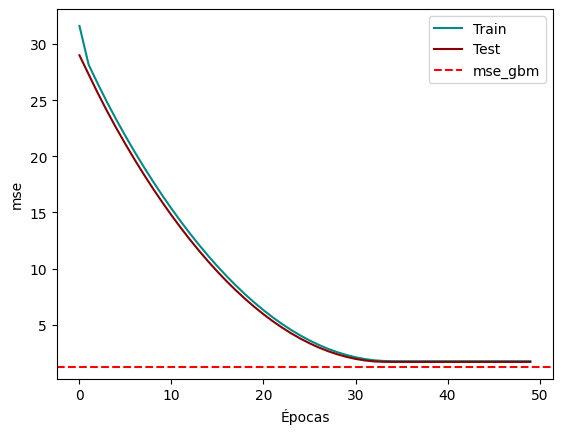

In [ ]:
plt.plot(train_losses, label='Train', c='darkcyan')
plt.plot(val_losses, label='Test', c='darkred')
plt.axhline(y=mse_gbm, color='r', linestyle='--', label='mse_gbm')
plt.xlabel('Épocas')
plt.ylabel('mse')
plt.legend()
plt.show()

## Clean memory

In [ ]:
del train_dataloader, val_dataloader, model
gc.collect()
torch.cuda.empty_cache()

## Model 2

In [ ]:
class model2(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.Linear1 = nn.Linear(in_features=hidden_size + 4, out_features=10)
        self.sigmoid = nn.Sigmoid()
        self.Linear2 = nn.Linear(in_features=10, out_features=1)
        self.drop = nn.Dropout(0.5)

    def forward(self, input_lingual, input_type, input_release_year, input_runtime, input_seasons):
        # input_lingual: (batch, time, features)
        sum_row = torch.mean(input_lingual, dim=1)
        sum_row = self.drop(sum_row)

        output = torch.cat((sum_row, input_type, input_release_year, input_runtime, input_seasons), dim=1)

        output = self.Linear1(output)
        output = self.sigmoid(output)
        output = self.Linear2(output)
        return output

In [ ]:
from torch.utils.data import DataLoader
BATCH_SIZE = 256 * 2

# then create your loaders as before:
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=custom_collate)
val_dataloader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, collate_fn=custom_collate)

LEARNING_RATE = 0.01

# Inicializa el modelo 
model = model2(hidden_size=768).to(device)

# Función de pérdida y optimizador
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

print(f"Modelo creado con {sum(p.numel() for p in model.parameters())} parámetros")

Modelo creado con 7741 parámetros


In [ ]:
NUM_EPOCHS = 50
train_losses, val_losses = train(model, train_dataloader, val_dataloader, optimizer, criterion, NUM_EPOCHS)

Iniciando entrenamiento...
--------------------------------------------------
Época 5/50
  Pérdida Entrenamiento: 1.7521
  Pérdida Testeo: 1.6771
  Empeorando
Época 10/50
  Pérdida Entrenamiento: 1.7521
  Pérdida Testeo: 1.6771
  Empeorando
Época 15/50
  Pérdida Entrenamiento: 1.7522
  Pérdida Testeo: 1.6771
  Empeorando
Época 20/50
  Pérdida Entrenamiento: 1.7522
  Pérdida Testeo: 1.6772
  Empeorando
Época 25/50
  Pérdida Entrenamiento: 1.7522
  Pérdida Testeo: 1.6772
  Empeorando
Época 30/50
  Pérdida Entrenamiento: 1.7523
  Pérdida Testeo: 1.6772
  Empeorando
Época 35/50
  Pérdida Entrenamiento: 1.7523
  Pérdida Testeo: 1.6772
  Empeorando
Época 40/50
  Pérdida Entrenamiento: 1.7523
  Pérdida Testeo: 1.6772
  Empeorando
Época 45/50
  Pérdida Entrenamiento: 1.7523
  Pérdida Testeo: 1.6772
  Empeorando
Época 50/50
  Pérdida Entrenamiento: 1.7523
  Pérdida Testeo: 1.6772
  Empeorando
Entrenamiento completado! Tiempo total: 115.43 segundos


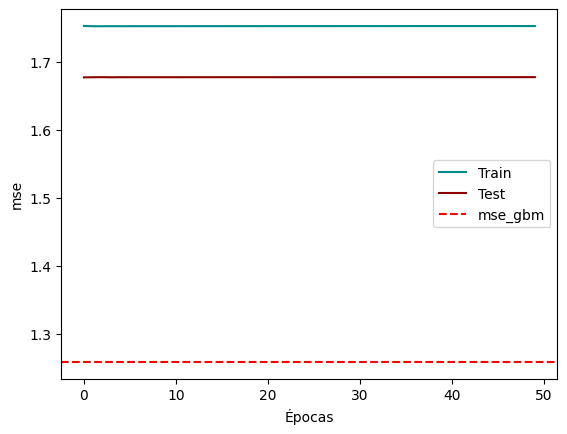

In [ ]:
plt.plot(train_losses, label='Train', c='darkcyan')
plt.plot(val_losses, label='Test', c='darkred')
plt.axhline(y=mse_gbm, color='r', linestyle='--', label='mse_gbm')
plt.xlabel('Épocas')
plt.ylabel('mse')
plt.legend()
plt.show()

## Modelo 3

In [18]:
# Load the BERT model
bertmodel = BertModel.from_pretrained(model_name).to(device).eval()

from torch.utils.data import Dataset

class dataset_token(Dataset):
    def __init__(self, titles, _hiddens):
        self.pairs = list(zip(_hiddens,
                              titles['type'],
                              titles['release_year'],
                              titles['runtime'],
                              titles['seasons'],
                              titles['imdb_score']))
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        _hidden, type, release_year, runtime, seasons, imdb_score = self.pairs[idx]
        out = {}

        out['input_lingual'] = _hidden.to(device)

        for name, feat in zip(NUMERICAL_FEATURES, [type, release_year, runtime, seasons]):
            out[f'input_{name}'] = torch.tensor(feat, dtype=torch.float).to(device)

        out['target'] = torch.tensor(imdb_score, dtype=torch.float).to(device)
        return out

def get_pooler_output_lingual(titles):
    titles_lingual = []

    with torch.inference_mode():
        for lingual in titles['lingual']:
            tokens = torch.tensor(tokenizer.encode(lingual, truncation=True)).to(device).unsqueeze(0)
            pooler_output = bertmodel(tokens).pooler_output[0]
            pooler_output = pooler_output.cpu()
            titles_lingual.append(pooler_output)
            torch.cuda.empty_cache()

    return titles_lingual

titles_train_hidden = get_pooler_output_lingual(titles_train)
titles_val_hidden = get_pooler_output_lingual(titles_val)

train_dataset = dataset_token(titles_train, titles_train_hidden)
val_dataset = dataset_token(titles_val, titles_val_hidden)

print('Primer elemento del dataset de entrenamiento:', train_dataset[1])

del bertmodel
torch.cuda.empty_cache()
gc.collect()

Primer elemento del dataset de entrenamiento: {'input_lingual': tensor([ 0.3389, -0.1237,  0.1605, -0.2367, -0.1795,  0.2128,  0.3784,  0.2676,
        -0.3899,  0.2407, -0.1113, -0.1270, -0.2113, -0.2071,  0.2041, -0.2593,
         0.5626,  0.0966,  0.1502, -0.3245, -1.0000, -0.1059, -0.3079, -0.0396,
        -0.3050,  0.1268, -0.2221,  0.1554,  0.1231, -0.0999,  0.0550, -1.0000,
         0.7261,  0.6425,  0.2689, -0.1650,  0.2529,  0.2164,  0.1561, -0.3975,
        -0.0673,  0.2350, -0.0738,  0.1450, -0.0772, -0.2695, -0.2227,  0.3191,
        -0.3555,  0.2056, -0.0232,  0.2278,  0.2934,  0.1978,  0.2952,  0.2807,
         0.2786,  0.2670,  0.2943, -0.2114,  0.0966,  0.1482,  0.1243, -0.1617,
        -0.2517, -0.4458,  0.0878, -0.1373,  0.4922, -0.2220, -0.1934, -0.3412,
        -0.1717,  0.1537, -0.0154, -0.2422,  0.3588,  0.2217,  0.1598, -0.2567,
        -0.3770, -0.3632, -0.2636,  0.1894, -0.1495,  0.2509,  0.2206, -0.3036,
         0.1291, -0.0600,  0.0698,  0.3758, -0.2118,  0.

5840

In [23]:
class model3(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.Linear1 = nn.Linear(in_features=hidden_size + 4, out_features=10)
        self.sigmoid = nn.Sigmoid()
        self.Linear2 = nn.Linear(in_features=10, out_features=1)
        self.drop = nn.Dropout(0.2)

    def forward(self, input_lingual, input_type, input_release_year, input_runtime, input_seasons):
        # input_lingual: (batch, time, features)
        
        sum_row = self.drop(input_lingual)

        output = torch.cat((sum_row, input_type, input_release_year, input_runtime, input_seasons), dim=1)

        output = self.Linear1(output)
        output = self.sigmoid(output)
        output = self.Linear2(output)
        return output

In [24]:
from torch.utils.data import DataLoader
BATCH_SIZE = 256 * 2

# then create your loaders as before:
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=custom_collate)
val_dataloader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, collate_fn=custom_collate)

LEARNING_RATE = 0.01

# Inicializa el modelo 
model = model3(hidden_size=768).to(device)

# Función de pérdida y optimizador
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

print(f"Modelo creado con {sum(p.numel() for p in model.parameters())} parámetros")

Modelo creado con 7741 parámetros


In [25]:
NUM_EPOCHS = 50
train_losses, val_losses = train(model, train_dataloader, val_dataloader, optimizer, criterion, NUM_EPOCHS)

Iniciando entrenamiento...
--------------------------------------------------
Época 5/50
  Pérdida Entrenamiento: 4.4219
  Pérdida Testeo: 2.8311
  Mejorando
Época 10/50
  Pérdida Entrenamiento: 1.7538
  Pérdida Testeo: 1.6777
  Mejorando
Época 15/50
  Pérdida Entrenamiento: 1.7521
  Pérdida Testeo: 1.6773
  Empeorando
Época 20/50
  Pérdida Entrenamiento: 1.7523
  Pérdida Testeo: 1.6772
  Empeorando
Época 25/50
  Pérdida Entrenamiento: 1.7524
  Pérdida Testeo: 1.6772
  Empeorando
Época 30/50
  Pérdida Entrenamiento: 1.7524
  Pérdida Testeo: 1.6773
  Empeorando
Época 35/50
  Pérdida Entrenamiento: 1.7525
  Pérdida Testeo: 1.6773
  Empeorando
Época 40/50
  Pérdida Entrenamiento: 1.7525
  Pérdida Testeo: 1.6773
  Empeorando
Época 45/50
  Pérdida Entrenamiento: 1.7525
  Pérdida Testeo: 1.6774
  Empeorando
Época 50/50
  Pérdida Entrenamiento: 1.7526
  Pérdida Testeo: 1.6774
  Empeorando
Entrenamiento completado! Tiempo total: 91.05 segundos


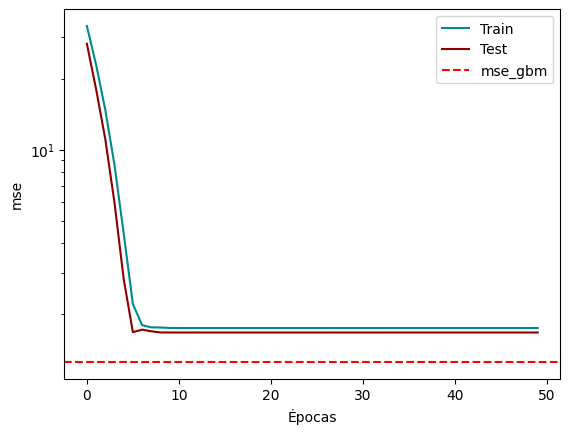

In [28]:
plt.plot(train_losses, label='Train', c='darkcyan')
plt.plot(val_losses, label='Test', c='darkred')
plt.axhline(y=mse_gbm, color='r', linestyle='--', label='mse_gbm')
plt.xlabel('Épocas')
plt.ylabel('mse')
plt.yscale('log')
plt.legend()
plt.show()

## Model 4

In [19]:
class gruregressor4(nn.Module):
    def __init__(self, seq_len, hidden_size):
        super().__init__()
        self.GRU1 = nn.GRU(input_size=seq_len, hidden_size=hidden_size, batch_first=True, bidirectional=True)
        self.attn = nn.Linear(2*hidden_size, 1)
        self.Linear1 = nn.Linear(in_features=2*hidden_size + 4, out_features=hidden_size)
        self.Tanh = nn.Tanh()
        self.Linear2 = nn.Linear(in_features=hidden_size, out_features=1)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, input_seq, input_type, input_release_year, input_runtime, input_seasons):
        # input_seq: (batch, time, features)
        out, _ = self.GRU1(input_seq)
        # attention
        attn_weights = torch.softmax(self.attn(out).squeeze(-1), dim=1)  # (batch, time)
        context = torch.sum(out * attn_weights.unsqueeze(-1), dim=1)     # (batch, 2*hidden_size)
        context = self.dropout(context)

        # concatenar con las características numéricas
        context = torch.cat((context, input_type, input_release_year, input_runtime, input_seasons), dim=1)
        context = self.Linear1(context)
        context = self.Tanh(context)
        outputs = self.Linear2(context)
        return outputs

In [23]:
from torch.utils.data import DataLoader
BATCH_SIZE = 64

# then create your loaders as before:
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=custom_collate)
val_dataloader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, collate_fn=custom_collate)

LEARNING_RATE = 0.001

# Inicializa el modelo 
model = gruregressor4(seq_len=768, hidden_size=32).to(device)

# Función de pérdida y optimizador
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

print(f"Modelo creado con {sum(p.numel() for p in model.parameters())} parámetros")

Modelo creado con 156290 parámetros


In [24]:
NUM_EPOCHS = 50
train_losses, val_losses = train(model, train_dataloader, val_dataloader, optimizer, criterion, NUM_EPOCHS)

Iniciando entrenamiento...
--------------------------------------------------
Época 5/50
  Pérdida Entrenamiento: 1.7589
  Pérdida Testeo: 1.6830
  Mejorando
Época 10/50
  Pérdida Entrenamiento: 1.7591
  Pérdida Testeo: 1.6828
  Mejorando
Época 15/50
  Pérdida Entrenamiento: 1.7592
  Pérdida Testeo: 1.6827
  Mejorando
Época 20/50
  Pérdida Entrenamiento: 1.7592
  Pérdida Testeo: 1.6827
  Mejorando
Época 25/50
  Pérdida Entrenamiento: 1.7592
  Pérdida Testeo: 1.6827
  Mejorando
Época 30/50
  Pérdida Entrenamiento: 1.7592
  Pérdida Testeo: 1.6827
  Mejorando
Época 35/50
  Pérdida Entrenamiento: 1.7592
  Pérdida Testeo: 1.6827
  Mejorando
Época 40/50
  Pérdida Entrenamiento: 1.7592
  Pérdida Testeo: 1.6826
  Mejorando
Época 45/50
  Pérdida Entrenamiento: 1.7592
  Pérdida Testeo: 1.6826
  Mejorando
Época 50/50
  Pérdida Entrenamiento: 1.7592
  Pérdida Testeo: 1.6826
  Mejorando
Entrenamiento completado! Tiempo total: 153.82 segundos


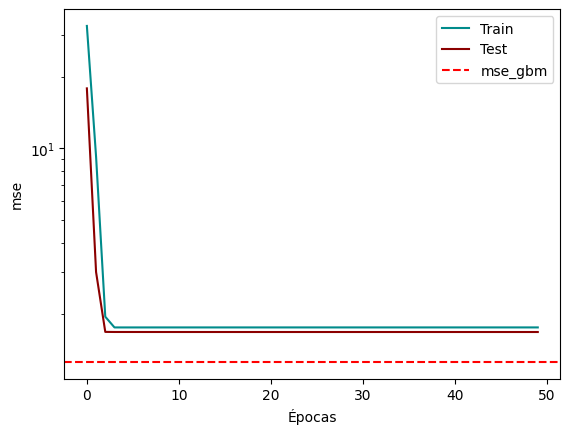

In [25]:
plt.plot(train_losses, label='Train', c='darkcyan')
plt.plot(val_losses, label='Test', c='darkred')
plt.axhline(y=mse_gbm, color='r', linestyle='--', label='mse_gbm')
plt.xlabel('Épocas')
plt.ylabel('mse')
plt.yscale('log')
plt.legend()
plt.show()